# Solar home electricity data

Source: http://www.ausgrid.com.au/Common/About-us/Corporate-information/Data-to-share/Solar-home-electricity-data.aspx

PH April-May 2017

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Get the parent directory
parent_folder = os.path.dirname(os.getcwd())
# add the parent directory to the Python path so that the scripts can be imported
sys.path.append(parent_folder)

In [3]:
%matplotlib inline

In [4]:
pd.__version__

'2.2.3'

## Load raw data

In [5]:
# fname = 'data/Solar home 2012-2013.csv'
fname = '../data/ausgrid/2012-2013 Solar home electricity data.csv'

In [6]:
!head -n 3 "$fname"

"2012-2013 Solar home electricity data - Before using this data, please read the attached pdf document ""Ausgrid solar home electricity data notes (Aug 2014).pdf""",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Customer,Generator Capacity,Postcode,Consumption Category,date,0:30,1:00,1:30,2:00,2:30,3:00,3:30,4:00,4:30,5:00,5:30,6:00,6:30,7:00,7:30,8:00,8:30,9:00,9:30,10:00,10:30,11:00,11:30,12:00,12:30,13:00,13:30,14:00,14:30,15:00,15:30,16:00,16:30,17:00,17:30,18:00,18:30,19:00,19:30,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00,Row Quality
1,3.78,2076,CL,1/07/2012,1.25,1.25,1.25,1.263,0.131,0.569,0.556,0,0,0.95,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.081,


### Parse CSV

(nb: parsing date is quite long):

In [7]:
# d_raw = pd.read_csv(fname, skiprows=1,
#                     parse_dates=['date'], dayfirst=True,
#                     na_filter=False, dtype={'Row Quality': str})
# Use this with explicit format:
d_raw = pd.read_csv(fname, skiprows=1,
                    parse_dates=['date'],
                    date_format='%d-%b-%y',
                    na_filter=False, dtype={'Row Quality': str})
len(d_raw)

268557

### Overview

rows seems ordered by: Customer / Consumption Category / date

In [8]:
d_raw.head()

,Customer,Generator Capacity,Postcode,Consumption Category,date,0:30,1:00,1:30,2:00,2:30,...,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00,Row Quality
0,1,3.78,2076,CL,1/07/2012,1.250,1.250,1.250,1.263,0.131,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.081,
1,1,3.78,2076,GC,1/07/2012,0.855,0.786,0.604,0.544,0.597,...,0.374,0.447,0.549,0.136,0.288,0.181,0.651,0.090,0.068,
2,1,3.78,2076,GG,1/07/2012,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,
3,1,3.78,2076,CL,2/07/2012,1.250,1.250,1.125,0.000,0.925,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.069,
4,1,3.78,2076,GC,2/07/2012,0.309,0.082,0.059,0.097,0.290,...,0.353,0.464,0.229,0.811,0.222,0.306,1.034,0.136,0.067,


In [9]:
d_raw.tail()

,Customer,Generator Capacity,Postcode,Consumption Category,date,0:30,1:00,1:30,2:00,2:30,...,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00,Row Quality
268552,300,3.36,2086,GC,29/06/2013,0.171,0.832,0.440,0.745,0.149,...,0.383,0.404,0.367,0.398,0.350,0.228,0.170,0.139,0.171,
268553,300,3.36,2086,GG,29/06/2013,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,
268554,300,3.36,2086,CL,30/06/2013,2.501,2.475,2.491,2.508,2.490,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.468,
268555,300,3.36,2086,GC,30/06/2013,0.150,0.158,0.157,0.137,0.163,...,0.625,0.595,0.695,0.646,0.581,0.458,0.472,0.732,0.297,
268556,300,3.36,2086,GG,30/06/2013,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,


In [10]:
# conver the date to datetime
d_raw['date'] = pd.to_datetime(d_raw['date'], format='%d/%m/%Y')
d_raw.head()

,Customer,Generator Capacity,Postcode,Consumption Category,date,0:30,1:00,1:30,2:00,2:30,...,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00,Row Quality
0,1,3.78,2076,CL,2012-07-01,1.250,1.250,1.250,1.263,0.131,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.081,
1,1,3.78,2076,GC,2012-07-01,0.855,0.786,0.604,0.544,0.597,...,0.374,0.447,0.549,0.136,0.288,0.181,0.651,0.090,0.068,
2,1,3.78,2076,GG,2012-07-01,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,
3,1,3.78,2076,CL,2012-07-02,1.250,1.250,1.125,0.000,0.925,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.069,
4,1,3.78,2076,GC,2012-07-02,0.309,0.082,0.059,0.097,0.290,...,0.353,0.464,0.229,0.811,0.222,0.306,1.034,0.136,0.067,


### Details on major columns

#### Post codes: 

* 100 different codes
* between 2008 and 2330, which corresponds to New South Wales (cf. [Postcodes_in_Australia](https://en.wikipedia.org/wiki/Postcodes_in_Australia)), as said by Ausgrid
* Postcode geocoding: [Postcodes location.ipynb](Postcodes location.ipynb)
* Geocoding output: [postcodes.csv](postcodes/postcodes.csv)

![New South Wales](https://upload.wikimedia.org/wikipedia/commons/thumb/a/a8/New_South_Wales_in_Australia.svg/267px-New_South_Wales_in_Australia.svg.png)

In [11]:
len(d_raw.Postcode.unique())

100

In [12]:
print(sorted(d_raw.Postcode.unique()))

[np.int64(2008), np.int64(2010), np.int64(2018), np.int64(2021), np.int64(2025), np.int64(2026), np.int64(2029), np.int64(2031), np.int64(2034), np.int64(2037), np.int64(2039), np.int64(2041), np.int64(2044), np.int64(2046), np.int64(2047), np.int64(2048), np.int64(2066), np.int64(2074), np.int64(2076), np.int64(2077), np.int64(2079), np.int64(2081), np.int64(2082), np.int64(2084), np.int64(2085), np.int64(2086), np.int64(2087), np.int64(2088), np.int64(2092), np.int64(2093), np.int64(2096), np.int64(2099), np.int64(2100), np.int64(2111), np.int64(2119), np.int64(2120), np.int64(2126), np.int64(2134), np.int64(2135), np.int64(2137), np.int64(2154), np.int64(2159), np.int64(2162), np.int64(2190), np.int64(2196), np.int64(2198), np.int64(2200), np.int64(2203), np.int64(2204), np.int64(2205), np.int64(2207), np.int64(2208), np.int64(2209), np.int64(2211), np.int64(2216), np.int64(2218), np.int64(2219), np.int64(2220), np.int64(2224), np.int64(2227), np.int64(2228), np.int64(2229), np.int6

#### Dates

* `parse_date` option is working (although quite slow)
* `dayfirst=True` is needed to avoid date inversions

In [13]:
d_raw.date.head()

0   2012-07-01
1   2012-07-01
2   2012-07-01
3   2012-07-02
4   2012-07-02
Name: date, dtype: datetime64[ns]

In [14]:
%time min(d_raw.date)

CPU times: user 103 ms, sys: 107 µs, total: 103 ms
Wall time: 103 ms


Timestamp('2012-07-01 00:00:00')

In [15]:
%time d_raw.date.min()

CPU times: user 1.15 ms, sys: 133 µs, total: 1.28 ms
Wall time: 746 µs


Timestamp('2012-07-01 00:00:00')

In [16]:
d0, d1 = d_raw.date.min(), d_raw.date.max()
d0, d1

(Timestamp('2012-07-01 00:00:00'), Timestamp('2013-06-30 00:00:00'))

#### Row Quality:

Ausgrid description:
> (Blank) = every half hour value in the row is the actual electricity
recorded by the meter in the half hour
>
> NA = Non-Actual where some or all of the half hour values in the
row are estimates or substitutes of the electricity consumed or
generated

Specifying the `dtype={'Row Quality': str}` is needed to avoid a columns of dtype float, filled with NaN.

In [17]:
if 'Row Quality' in d_raw.columns:
    d_raw['Row Quality'].unique()

In [18]:
if 'Row Quality' in d_raw.columns:
    d_raw['Row Quality'].value_counts()

#### Customers

300 unique values, from 1 to 300

In [19]:
len(d_raw['Customer'].unique())

300

In [20]:
d_raw['Customer'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

#### Consumption Category (aka measurement channel)

From Ausgrid description:

> **GC** = General Consumption for electricity supplied all the time
(primary tariff, either inclining block or time of use rates),
excluding solar generation and controlled load supply

> **CL** = Controlled Load Consumption (Off peak 1 or 2 tariffs)

> **GG** = Gross Generation for electricity generated by the solar
system with a gross metering configuration, measured separately
to household loads

Observation: only half as much CL as GG and GC.


In [21]:
d_raw['Consumption Category'].unique()

array(['CL', 'GC', 'GG'], dtype=object)

In [22]:
d_raw['Consumption Category'].value_counts()

Consumption Category
GC    109419
GG    109419
CL     49719
Name: count, dtype: int64

### Completeness of the record

there are some missing records in the dataframe:

* GG and GC is complete
* Some 54% of CL is missing.

In [23]:
len(d_raw)/366/300

2.4458743169398907

In [24]:
d_raw['Consumption Category'].value_counts()/300/366

Consumption Category
GC    0.996530
GG    0.996530
CL    0.452814
Name: count, dtype: float64

## 2) Reshaping the data set.

Objective:

* Stack the time, to get proper timestamp combining day and hour
* pivot the customer and consumption category as columns

### Create datetime index

In [25]:
from pandas.tseries.offsets import Day

In [26]:
d1 = pd.to_datetime(d1)

In [27]:
d1 + Day(1)

Timestamp('2013-07-01 00:00:00')

Create the index, with **"left" convention** (start of the 30min interval), to make slicing for a given day easier

In [28]:
index = pd.date_range(d0, d1 + Day(1), freq='30T', inclusive='left')
index

/tmp/ipykernel_95472/2707357368.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  index = pd.date_range(d0, d1 + Day(1), freq='30T', inclusive='left')


DatetimeIndex(['2012-07-01 00:00:00', '2012-07-01 00:30:00',
               '2012-07-01 01:00:00', '2012-07-01 01:30:00',
               '2012-07-01 02:00:00', '2012-07-01 02:30:00',
               '2012-07-01 03:00:00', '2012-07-01 03:30:00',
               '2012-07-01 04:00:00', '2012-07-01 04:30:00',
               ...
               '2013-06-30 19:00:00', '2013-06-30 19:30:00',
               '2013-06-30 20:00:00', '2013-06-30 20:30:00',
               '2013-06-30 21:00:00', '2013-06-30 21:30:00',
               '2013-06-30 22:00:00', '2013-06-30 22:30:00',
               '2013-06-30 23:00:00', '2013-06-30 23:30:00'],
              dtype='datetime64[ns]', length=17520, freq='30min')

### Colums: Customer/Channel

using a MultiIndex, cf. [MultiIndex / Advanced Indexing](http://pandas.pydata.org/pandas-docs/stable/advanced.html) doc.

In [29]:
customers = sorted(d_raw.Customer.unique())
print(customers)

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), 

In [30]:
channels = d_raw['Consumption Category'].unique()
channels

array(['CL', 'GC', 'GG'], dtype=object)

Customized channel order:

* Consumption first (GC)
* PV Generation second (GG)
* CL third, because it is not always present (small trick to preserve the channel color in plots)

In [31]:
channels = ['GC', 'GG', 'CL']

In [32]:
columns = pd.MultiIndex.from_product(
    (customers, channels), names=['Customer', 'Channel'])
columns

MultiIndex([(  1, 'GC'),
            (  1, 'GG'),
            (  1, 'CL'),
            (  2, 'GC'),
            (  2, 'GG'),
            (  2, 'CL'),
            (  3, 'GC'),
            (  3, 'GG'),
            (  3, 'CL'),
            (  4, 'GC'),
            ...
            (297, 'CL'),
            (298, 'GC'),
            (298, 'GG'),
            (298, 'CL'),
            (299, 'GC'),
            (299, 'GG'),
            (299, 'CL'),
            (300, 'GC'),
            (300, 'GG'),
            (300, 'CL')],
           names=['Customer', 'Channel'], length=900)

### Create the new DataFrame

starting from a blank DataFrame:

In [33]:
# empty_cols = pd.MultiIndex(
#     levels=[customers, channels],
#     labels=[[],  []],
#     names=['Customer', 'Channel'])
empty_cols = pd.MultiIndex(
    levels=[customers, channels],
    codes=[[],  []],
    names=['Customer', 'Channel'])

In [34]:
df = pd.DataFrame(index=index, columns=empty_cols)
df

2012-07-01 00:00:00
2012-07-01 00:30:00
2012-07-01 01:00:00
2012-07-01 01:30:00
2012-07-01 02:00:00
...
2013-06-30 21:30:00
2013-06-30 22:00:00
2013-06-30 22:30:00
2013-06-30 23:00:00
2013-06-30 23:30:00


Fill the columns:

notice: 

* it is way slower when the 3x300 columns are pre-assigned in the DataFrame creation
* but the MultiIndex is lost when pre-assignment is not done (empty columns)
* → solution which seems to work: using an empty MultiIndex (customers/channel)

In [35]:
missing_records = []

for c in customers:
    d_c = d_raw[d_raw.Customer == c]

    # TODO: save the row quality
    print(c, end=', ')

    for ch in channels:  # Loop through each consumption category (GC, GG, CL)
        # Filter data for current customer and channel
        d_c_ch = d_c[d_c['Consumption Category'] == ch]
        ts = d_c_ch.iloc[:, 5:-1].values.ravel()  # Extract time series data
        # from index 5 to the second-to-last column (5:-1)
        # if len(ts) > 0:  # Check if data length matches expected length
        #     df[c, ch] = ts
        # else:
        #     missing_records.append((c, ch, len(ts)))
        if len(ts) != len(index):  # Check if data length matches expected length
            # Track missing/incomplete records
            missing_records.append((c, ch, len(ts)))
        else:
            df[c, ch] = ts  # Store the time series in the DataFrame

1, 

/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts  # Store the time series in the DataFrame
/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts  # Store the time series in the DataFrame
/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) ins

2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 

/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts  # Store the time series in the DataFrame
/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts  # Store the time series in the DataFrame
/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) ins

108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 

/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts  # Store the time series in the DataFrame
/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts  # Store the time series in the DataFrame
/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) ins

208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 

/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts  # Store the time series in the DataFrame
/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts  # Store the time series in the DataFrame
/tmp/ipykernel_95472/1882852989.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) ins

#### Analysis of missing/imcomplete records

Observation: out of 162 missing records (over a potential of 900):

* 161 are the complete absence of the CL channel
* 1 is an incomplete CL channe (from 2011-07-01 to 2012-01-12): maybe a change of tariff ?

In [36]:
len(columns)

900

In [37]:
len(missing_records)

175

In [38]:
n_empty_CL = 0
missing_records_others = []
for (c, ch, len_ts) in missing_records:
    if ch == 'CL' and len_ts == 0:
        n_empty_CL += 1
    else:
        missing_records_others.append((c, ch, len_ts))
n_empty_CL

162

In [39]:
missing_records_others

[(np.int64(2), 'GC', 13632),
 (np.int64(2), 'GG', 13632),
 (np.int64(2), 'CL', 13632),
 (np.int64(68), 'CL', 14400),
 (np.int64(95), 'CL', 15264),
 (np.int64(161), 'CL', 14688),
 (np.int64(187), 'CL', 14736),
 (np.int64(248), 'CL', 15360),
 (np.int64(272), 'CL', 14400),
 (np.int64(284), 'CL', 14400),
 (np.int64(289), 'CL', 14640),
 (np.int64(293), 'CL', 15216),
 (np.int64(294), 'CL', 14736)]

#### Check the new dataframe

In [40]:
len(df.columns) + len(missing_records)

900

In [41]:
df.shape

(17520, 725)

In [42]:
df.head()

Customer               1                  3                4                \
Channel                 GC   GG     CL     GC   GG   CL     GC   GG     CL   
2012-07-01 00:00:00  0.855  0.0  1.250  0.965  0.0  0.0  0.084  0.0  0.000   
2012-07-01 00:30:00  0.786  0.0  1.250  0.927  0.0  0.0  0.084  0.0  0.000   
2012-07-01 01:00:00  0.604  0.0  1.250  1.359  0.0  0.0  0.082  0.0  1.930   
2012-07-01 01:30:00  0.544  0.0  1.263  0.060  0.0  0.0  0.084  0.0  1.978   
2012-07-01 02:00:00  0.597  0.0  0.131  0.059  0.0  0.0  0.086  0.0  0.784   

Customer               5    ...    297               298         299       \
Channel                 GC  ...     GC   GG    CL     GC   GG     GC   GG   
2012-07-01 00:00:00  0.108  ...  0.141  0.0  0.00  0.157  0.0  0.541  0.0   
2012-07-01 00:30:00  0.098  ...  0.257  0.0  0.00  0.127  0.0  0.100  0.0   
2012-07-01 01:00:00  0.105  ...  0.197  0.0  0.00  0.122  0.0  0.090  0.0   
2012-07-01 01:30:00  0.075  ...  0.273  0.0  1.33  0.120  0.0  0.094  0.0   
2012-07-01 02:00:00  0.102  ...  0.206  0.0  0.00  0.106  0.0  0.046  0.0   

Customer               300              
Channel                 GC   GG     CL  
2012-07-01 00:00:00  0.219  0.0  2.673  
2012-07-01 00:30:00  0.099  0.0  1.246  
2012-07-01 01:00:00  0.134  0.0  0.000  
2012-07-01 01:30:00  0.100  0.0  0.000  
2012-07-01 02:00:00  0.123  0.0  0.000  

[5 rows x 725 columns]

In [43]:
df.tail()

Customer               1                  3                4              \
Channel                 GC   GG     CL     GC   GG   CL     GC   GG   CL   
2013-06-30 21:30:00  0.274  0.0  0.000  0.056  0.0  0.0  0.134  0.0  0.0   
2013-06-30 22:00:00  0.509  0.0  0.000  0.056  0.0  0.0  0.137  0.0  0.0   
2013-06-30 22:30:00  0.166  0.0  0.000  0.065  0.0  0.0  0.140  0.0  0.0   
2013-06-30 23:00:00  0.861  0.0  0.000  0.063  0.0  0.0  0.112  0.0  0.0   
2013-06-30 23:30:00  0.631  0.0  1.056  0.052  0.0  0.0  0.107  0.0  0.0   

Customer               5    ...    297                298         299       \
Channel                 GC  ...     GC   GG     CL     GC   GG     GC   GG   
2013-06-30 21:30:00  0.390  ...  0.167  0.0  0.000  0.267  0.0  0.618  0.0   
2013-06-30 22:00:00  0.413  ...  0.179  0.0  0.775  0.273  0.0  0.568  0.0   
2013-06-30 22:30:00  1.068  ...  0.181  0.0  2.413  0.247  0.0  0.832  0.0   
2013-06-30 23:00:00  1.084  ...  0.171  0.0  1.095  0.149  0.0  0.760  0.0   
2013-06-30 23:30:00  0.999  ...  0.177  0.0  0.000  0.138  0.0  0.150  0.0   

Customer               300              
Channel                 GC   GG     CL  
2013-06-30 21:30:00  0.581  0.0  0.000  
2013-06-30 22:00:00  0.458  0.0  0.000  
2013-06-30 22:30:00  0.472  0.0  0.000  
2013-06-30 23:00:00  0.732  0.0  0.000  
2013-06-30 23:30:00  0.297  0.0  2.468  

[5 rows x 725 columns]

### Unit conversion: kWh → kW → W

Energy records in the original CSV file is in kWh on the 30 min interval. Convert to kW.

In [44]:
df

Customer               1                  3                4                \
Channel                 GC   GG     CL     GC   GG   CL     GC   GG     CL   
2012-07-01 00:00:00  0.855  0.0  1.250  0.965  0.0  0.0  0.084  0.0  0.000   
2012-07-01 00:30:00  0.786  0.0  1.250  0.927  0.0  0.0  0.084  0.0  0.000   
2012-07-01 01:00:00  0.604  0.0  1.250  1.359  0.0  0.0  0.082  0.0  1.930   
2012-07-01 01:30:00  0.544  0.0  1.263  0.060  0.0  0.0  0.084  0.0  1.978   
2012-07-01 02:00:00  0.597  0.0  0.131  0.059  0.0  0.0  0.086  0.0  0.784   
...                    ...  ...    ...    ...  ...  ...    ...  ...    ...   
2013-06-30 21:30:00  0.274  0.0  0.000  0.056  0.0  0.0  0.134  0.0  0.000   
2013-06-30 22:00:00  0.509  0.0  0.000  0.056  0.0  0.0  0.137  0.0  0.000   
2013-06-30 22:30:00  0.166  0.0  0.000  0.065  0.0  0.0  0.140  0.0  0.000   
2013-06-30 23:00:00  0.861  0.0  0.000  0.063  0.0  0.0  0.112  0.0  0.000   
2013-06-30 23:30:00  0.631  0.0  1.056  0.052  0.0  0.0  0.107  0.0  0.000   

Customer               5    ...    297                298         299       \
Channel                 GC  ...     GC   GG     CL     GC   GG     GC   GG   
2012-07-01 00:00:00  0.108  ...  0.141  0.0  0.000  0.157  0.0  0.541  0.0   
2012-07-01 00:30:00  0.098  ...  0.257  0.0  0.000  0.127  0.0  0.100  0.0   
2012-07-01 01:00:00  0.105  ...  0.197  0.0  0.000  0.122  0.0  0.090  0.0   
2012-07-01 01:30:00  0.075  ...  0.273  0.0  1.330  0.120  0.0  0.094  0.0   
2012-07-01 02:00:00  0.102  ...  0.206  0.0  0.000  0.106  0.0  0.046  0.0   
...                    ...  ...    ...  ...    ...    ...  ...    ...  ...   
2013-06-30 21:30:00  0.390  ...  0.167  0.0  0.000  0.267  0.0  0.618  0.0   
2013-06-30 22:00:00  0.413  ...  0.179  0.0  0.775  0.273  0.0  0.568  0.0   
2013-06-30 22:30:00  1.068  ...  0.181  0.0  2.413  0.247  0.0  0.832  0.0   
2013-06-30 23:00:00  1.084  ...  0.171  0.0  1.095  0.149  0.0  0.760  0.0   
2013-06-30 23:30:00  0.999  ...  0.177  0.0  0.000  0.138  0.0  0.150  0.0   

Customer               300              
Channel                 GC   GG     CL  
2012-07-01 00:00:00  0.219  0.0  2.673  
2012-07-01 00:30:00  0.099  0.0  1.246  
2012-07-01 01:00:00  0.134  0.0  0.000  
2012-07-01 01:30:00  0.100  0.0  0.000  
2012-07-01 02:00:00  0.123  0.0  0.000  
...                    ...  ...    ...  
2013-06-30 21:30:00  0.581  0.0  0.000  
2013-06-30 22:00:00  0.458  0.0  0.000  
2013-06-30 22:30:00  0.472  0.0  0.000  
2013-06-30 23:00:00  0.732  0.0  0.000  
2013-06-30 23:30:00  0.297  0.0  2.468  

[17520 rows x 725 columns]

In [45]:
df[1].mean()

Channel
GC    0.301363
GG    0.291964
CL    0.136947
dtype: float64

In [46]:
df *= 2

In [47]:
df[1].mean()

Channel
GC    0.602726
GG    0.583928
CL    0.273895
dtype: float64

In [48]:
# KW to W
df *= 1000

In [49]:
df[1].mean()

Channel
GC    602.726484
GG    583.927740
CL    273.894635
dtype: float64

## 3) Howto work with the reshaped DataFrame

### 3a) select *one* customer, with all its 3 channels

this easy because `customer` is the first level of the MultiIndex

In [50]:
df[1]

Channel,GC,GG,CL
2012-07-01 00:00:00,1710.0,0.0,2500.0
2012-07-01 00:30:00,1572.0,0.0,2500.0
2012-07-01 01:00:00,1208.0,0.0,2500.0
2012-07-01 01:30:00,1088.0,0.0,2526.0
2012-07-01 02:00:00,1194.0,0.0,262.0
...,...,...,...
2013-06-30 21:30:00,548.0,0.0,0.0
2013-06-30 22:00:00,1018.0,0.0,0.0
2013-06-30 22:30:00,332.0,0.0,0.0
2013-06-30 23:00:00,1722.0,0.0,0.0


In [51]:
df[1].mean()

Channel
GC    602.726484
GG    583.927740
CL    273.894635
dtype: float64

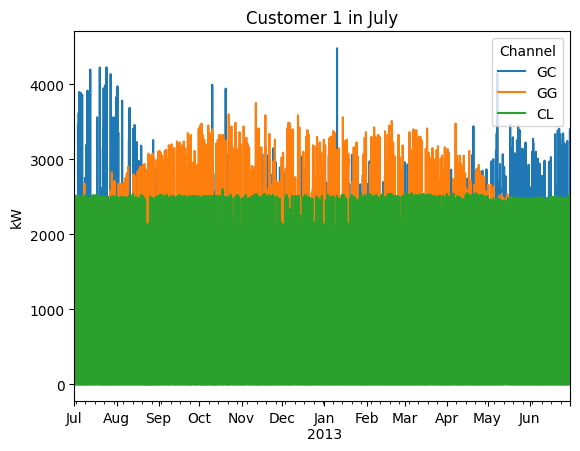

In [52]:
import os
df[1]['2012-07-01':'2013-07-03'].plot()
plt.title('Customer 1 in July')
plt.ylabel('kW')

# Create the directory if it doesn't exist
os.makedirs('../figs/ausgrid_explore', exist_ok=True)
plt.savefig('../figs/ausgrid_explore/Customer 1 2012-07 01-03.png', dpi=150)

Text(0.5, 1.0, 'Customer 100 in July (No CL)')

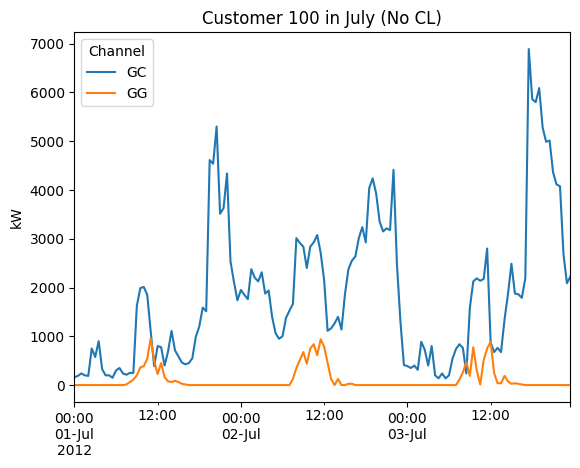

In [53]:
df[100]['2012-07-01':'2012-07-03'].plot()
plt.ylabel('kW')
plt.title('Customer 100 in July (No CL)')

### 3b) select *one* channel, across *all* customers

This is less easy because `channel` is the 2nd level of the MultiIndex.
It requires using [cross-section](http://pandas.pydata.org/pandas-docs/stable/advanced.html#cross-section) indexing with `xs`

In [54]:
dfGG = df.xs('GG', level='Channel', axis=1)
dfGG[[1, 4, 100]]

Customer,1,4,100
2012-07-01 00:00:00,0.0,0.0,0.0
2012-07-01 00:30:00,0.0,0.0,0.0
2012-07-01 01:00:00,0.0,0.0,0.0
2012-07-01 01:30:00,0.0,0.0,0.0
2012-07-01 02:00:00,0.0,0.0,0.0
...,...,...,...
2013-06-30 21:30:00,0.0,0.0,0.0
2013-06-30 22:00:00,0.0,0.0,0.0
2013-06-30 22:30:00,0.0,0.0,0.0
2013-06-30 23:00:00,0.0,0.0,0.0


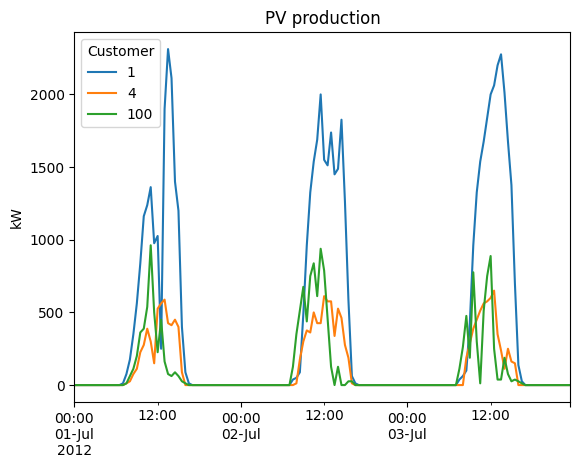

In [55]:
dfGG[[1, 4, 100]]['2012-07-01':'2012-07-03'].plot()
plt.title('PV production')
plt.ylabel('kW')
plt.savefig('../figs/ausgrid_explore/PV production 2012-07 01-03.png', dpi=150)

## Reorganize the data
Now we have MultiIndex columns in `df`, with Customer and Channel as the second level.

We want to have a SingleIndex columns, with names like 1_GC, 1_GG, 2_GC, 2_GG, etc.

In [56]:
df.head()

Customer                1                    3                4         \
Channel                  GC   GG      CL      GC   GG   CL     GC   GG   
2012-07-01 00:00:00  1710.0  0.0  2500.0  1930.0  0.0  0.0  168.0  0.0   
2012-07-01 00:30:00  1572.0  0.0  2500.0  1854.0  0.0  0.0  168.0  0.0   
2012-07-01 01:00:00  1208.0  0.0  2500.0  2718.0  0.0  0.0  164.0  0.0   
2012-07-01 01:30:00  1088.0  0.0  2526.0   120.0  0.0  0.0  168.0  0.0   
2012-07-01 02:00:00  1194.0  0.0   262.0   118.0  0.0  0.0  172.0  0.0   

Customer                       5    ...    297                 298       \
Channel                  CL     GC  ...     GC   GG      CL     GC   GG   
2012-07-01 00:00:00     0.0  216.0  ...  282.0  0.0     0.0  314.0  0.0   
2012-07-01 00:30:00     0.0  196.0  ...  514.0  0.0     0.0  254.0  0.0   
2012-07-01 01:00:00  3860.0  210.0  ...  394.0  0.0     0.0  244.0  0.0   
2012-07-01 01:30:00  3956.0  150.0  ...  546.0  0.0  2660.0  240.0  0.0   
2012-07-01 02:00:00  1568.0  204.0  ...  412.0  0.0     0.0  212.0  0.0   

Customer                299         300               
Channel                  GC   GG     GC   GG      CL  
2012-07-01 00:00:00  1082.0  0.0  438.0  0.0  5346.0  
2012-07-01 00:30:00   200.0  0.0  198.0  0.0  2492.0  
2012-07-01 01:00:00   180.0  0.0  268.0  0.0     0.0  
2012-07-01 01:30:00   188.0  0.0  200.0  0.0     0.0  
2012-07-01 02:00:00    92.0  0.0  246.0  0.0     0.0  

[5 rows x 725 columns]

In [57]:
# Flatten MultiIndex columns to single-level columns
# Format: {Customer}_{Channel} (e.g., 1_GC, 1_GG, 2_GC, 2_GG, etc.)

df_flat = df.copy()
df_flat.columns = df_flat.columns.map(lambda x: f"{x[0]}_{x[1]}")
df_flat.head()

,1_GC,1_GG,1_CL,3_GC,3_GG,3_CL,4_GC,4_GG,4_CL,5_GC,...,297_GC,297_GG,297_CL,298_GC,298_GG,299_GC,299_GG,300_GC,300_GG,300_CL
2012-07-01 00:00:00,1710.0,0.0,2500.0,1930.0,0.0,0.0,168.0,0.0,0.0,216.0,...,282.0,0.0,0.0,314.0,0.0,1082.0,0.0,438.0,0.0,5346.0
2012-07-01 00:30:00,1572.0,0.0,2500.0,1854.0,0.0,0.0,168.0,0.0,0.0,196.0,...,514.0,0.0,0.0,254.0,0.0,200.0,0.0,198.0,0.0,2492.0
2012-07-01 01:00:00,1208.0,0.0,2500.0,2718.0,0.0,0.0,164.0,0.0,3860.0,210.0,...,394.0,0.0,0.0,244.0,0.0,180.0,0.0,268.0,0.0,0.0
2012-07-01 01:30:00,1088.0,0.0,2526.0,120.0,0.0,0.0,168.0,0.0,3956.0,150.0,...,546.0,0.0,2660.0,240.0,0.0,188.0,0.0,200.0,0.0,0.0
2012-07-01 02:00:00,1194.0,0.0,262.0,118.0,0.0,0.0,172.0,0.0,1568.0,204.0,...,412.0,0.0,0.0,212.0,0.0,92.0,0.0,246.0,0.0,0.0


To put GG, GC, CL into our case，create a new dataframe with the following rules for each customer:
pv=GG
con=GC+CL
net=con-pv
note that some customers have no CL, so we need to fill the NaN values with 0.
Let's start from `df_flat`.

In [58]:
# Efficient implementation using pd.concat to avoid DataFrame fragmentation
# Starting from df_flat with columns like 1_GC, 1_GG, 1_CL, 2_GC, 2_GG, 2_CL, etc.

# Get all unique customers
customers = sorted([int(col.split('_')[0])
                   for col in df_flat.columns if '_' in col])
customers = list(set(customers))

# Prepare data for each customer in a list of DataFrames
customer_dfs = []

for customer in customers:
    # Create a temporary DataFrame for this customer
    temp_df = pd.DataFrame(index=df_flat.index)

    # PV generation (GG)
    pv_col = f"{customer}_GG"
    if pv_col in df_flat.columns:
        temp_df[f"{customer}_pv"] = df_flat[pv_col]
    else:
        temp_df[f"{customer}_pv"] = 0

    # Total consumption (GC + CL, with CL filled with 0 if missing)
    gc_col = f"{customer}_GC"
    cl_col = f"{customer}_CL"

    if gc_col in df_flat.columns:
        gc_values = df_flat[gc_col]
    else:
        gc_values = 0

    if cl_col in df_flat.columns:
        cl_values = df_flat[cl_col].fillna(0)  # Fill NaN with 0
    else:
        cl_values = 0
    # Residential load is considered as consumption.
    # Residential load is considered as co
    temp_df[f"{customer}_con"] = gc_values
    # temp_df[f"{customer}_con"] = gc_values + cl_values
    # Net consumption (con - pv)
    temp_df[f"{customer}_net"] = temp_df[f"{customer}_con"] - \
        temp_df[f"{customer}_pv"]

    customer_dfs.append(temp_df)

# Concatenate all customer DataFrames at once (this avoids fragmentation)
df_our_case = pd.concat(customer_dfs, axis=1)

# Optional: defragment the final DataFrame
df_our_case = df_our_case.copy()

# Display the result
print("New dataframe structure:")
print(f"Shape: {df_our_case.shape}")
print(f"Columns: {list(df_our_case.columns)[:10]}...")  # Show first 10 columns
df_our_case.head()

New dataframe structure:
Shape: (17520, 897)
Columns: ['1_pv', '1_con', '1_net', '3_pv', '3_con', '3_net', '4_pv', '4_con', '4_net', '5_pv']...


,1_pv,1_con,1_net,3_pv,3_con,3_net,4_pv,4_con,4_net,5_pv,...,297_net,298_pv,298_con,298_net,299_pv,299_con,299_net,300_pv,300_con,300_net
2012-07-01 00:00:00,0.0,1710.0,1710.0,0.0,1930.0,1930.0,0.0,168.0,168.0,0.0,...,282.0,0.0,314.0,314.0,0.0,1082.0,1082.0,0.0,438.0,438.0
2012-07-01 00:30:00,0.0,1572.0,1572.0,0.0,1854.0,1854.0,0.0,168.0,168.0,0.0,...,514.0,0.0,254.0,254.0,0.0,200.0,200.0,0.0,198.0,198.0
2012-07-01 01:00:00,0.0,1208.0,1208.0,0.0,2718.0,2718.0,0.0,164.0,164.0,0.0,...,394.0,0.0,244.0,244.0,0.0,180.0,180.0,0.0,268.0,268.0
2012-07-01 01:30:00,0.0,1088.0,1088.0,0.0,120.0,120.0,0.0,168.0,168.0,0.0,...,546.0,0.0,240.0,240.0,0.0,188.0,188.0,0.0,200.0,200.0
2012-07-01 02:00:00,0.0,1194.0,1194.0,0.0,118.0,118.0,0.0,172.0,172.0,0.0,...,412.0,0.0,212.0,212.0,0.0,92.0,92.0,0.0,246.0,246.0


In [59]:
# make the datetime a column and put it first
df_our_case['datetime'] = df_our_case.index
df_our_case = df_our_case[['datetime'] +
                          [col for col in df_our_case.columns if col != 'datetime']]
# set the index to [0, 1, 2, ...]
df_our_case.index = range(len(df_our_case))
df_our_case.head()

,datetime,1_pv,1_con,1_net,3_pv,3_con,3_net,4_pv,4_con,4_net,...,297_net,298_pv,298_con,298_net,299_pv,299_con,299_net,300_pv,300_con,300_net
0,2012-07-01 00:00:00,0.0,1710.0,1710.0,0.0,1930.0,1930.0,0.0,168.0,168.0,...,282.0,0.0,314.0,314.0,0.0,1082.0,1082.0,0.0,438.0,438.0
1,2012-07-01 00:30:00,0.0,1572.0,1572.0,0.0,1854.0,1854.0,0.0,168.0,168.0,...,514.0,0.0,254.0,254.0,0.0,200.0,200.0,0.0,198.0,198.0
2,2012-07-01 01:00:00,0.0,1208.0,1208.0,0.0,2718.0,2718.0,0.0,164.0,164.0,...,394.0,0.0,244.0,244.0,0.0,180.0,180.0,0.0,268.0,268.0
3,2012-07-01 01:30:00,0.0,1088.0,1088.0,0.0,120.0,120.0,0.0,168.0,168.0,...,546.0,0.0,240.0,240.0,0.0,188.0,188.0,0.0,200.0,200.0
4,2012-07-01 02:00:00,0.0,1194.0,1194.0,0.0,118.0,118.0,0.0,172.0,172.0,...,412.0,0.0,212.0,212.0,0.0,92.0,92.0,0.0,246.0,246.0


In [60]:
# add HoD dow doy month	year
from modules.utils import add_datetime_columns
df_our_case = add_datetime_columns(df_our_case)
df_our_case.head()

,datetime,HoD,dow,doy,month,year,1_pv,1_con,1_net,3_pv,...,297_net,298_pv,298_con,298_net,299_pv,299_con,299_net,300_pv,300_con,300_net
0,2012-07-01 00:00:00,0,6,183,7,2012,0.0,1710.0,1710.0,0.0,...,282.0,0.0,314.0,314.0,0.0,1082.0,1082.0,0.0,438.0,438.0
1,2012-07-01 00:30:00,0,6,183,7,2012,0.0,1572.0,1572.0,0.0,...,514.0,0.0,254.0,254.0,0.0,200.0,200.0,0.0,198.0,198.0
2,2012-07-01 01:00:00,1,6,183,7,2012,0.0,1208.0,1208.0,0.0,...,394.0,0.0,244.0,244.0,0.0,180.0,180.0,0.0,268.0,268.0
3,2012-07-01 01:30:00,1,6,183,7,2012,0.0,1088.0,1088.0,0.0,...,546.0,0.0,240.0,240.0,0.0,188.0,188.0,0.0,200.0,200.0
4,2012-07-01 02:00:00,2,6,183,7,2012,0.0,1194.0,1194.0,0.0,...,412.0,0.0,212.0,212.0,0.0,92.0,92.0,0.0,246.0,246.0


## Save the data

In [61]:
df_our_case.to_csv('../data/ausgrid/ausgrid_2012_2013.csv')

## 4) Some stats

### 4a) PV generation capacity of each customer

observations:

* Generation capacity is constant over 2011-2012 (no generation upgrade)
* Mean at 1.68, *in agreement with data note* from Ausgrid (§ Summary statistics, p2)
* Most (75%) are between 1 and 2 kW.
* Some (2%) are around 6, 8 or 10 kW.

In [62]:
d_cust_cap = d_raw[['Customer', 'Generator Capacity']]
d_cust_cap.iloc[[0,  1, 2000, -1]]

,Customer,Generator Capacity
0,1,3.78
1,1,3.78
2000,3,1.00
268556,300,3.36


Check if the generator capacity is constant for each customer:

In [63]:
d_cust_cap.groupby('Customer')['Generator Capacity'].nunique().value_counts()

Generator Capacity
1    300
Name: count, dtype: int64

In [64]:
gen_cap = d_cust_cap.groupby('Customer')['Generator Capacity'].mean()
gen_cap.describe(percentiles=[0.5, 0.8, 0.9, 0.980])

count    300.000000
mean       1.683300
std        1.036846
min        1.000000
50%        1.500000
80%        2.040000
90%        2.728000
98%        4.571200
max        9.990000
Name: Generator Capacity, dtype: float64

[Text(0.5, 0, 'PV gen capacity (kW)')]

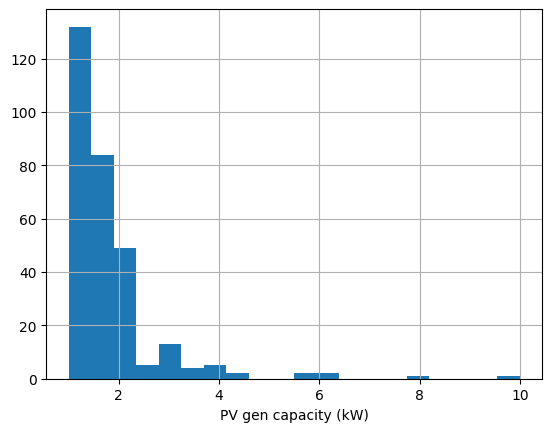

In [65]:
ax = gen_cap.hist(bins=20)
ax.set(xlabel='PV gen capacity (kW)')
#  ax.set_yscale('log')

### 4b) Yield of PV generation 

* annual generation (kWh)
* sun hours/year (kWh/kWp)

#### Check of one customer

In [66]:
gen_cap[1]

np.float64(3.7799999999999994)

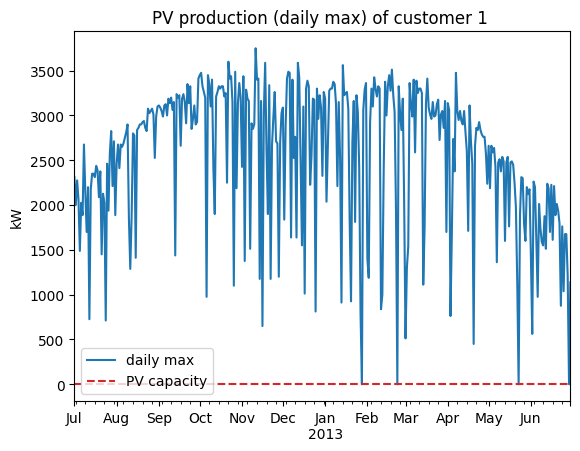

In [67]:
dfGG[1].resample('1D').max().plot(label='daily max')
plt.title('PV production (daily max) of customer 1 ')
plt.ylabel('kW')
plt.hlines(gen_cap[1], df.index[0], df.index[-1],
           linestyles='dashed', color='tab:red', label='PV capacity')
plt.legend()

#### Global statistics of PV generation

* Production mean and median *in agreement with data note* from Ausgrid (§ Summary statistics, p2)

* Normalized by capacity: **1231 hours/y** averaged across all customers
* All are above 800 hours/y, except 4 customers

NB: the coast around Sidney's has a GHI between 4-5 kWh/m²/day, that is **1500-1800 kWh/m²/y**

<img src='external/SolarGIS Australia GHI map south.png' alt='Australia GHI map' style='width:50em'>

In [68]:
dt = 0.5   # hours
GG_year = dfGG.sum()*dt
GG_year.mean(), GG_year.median()

(np.float64(2182567.4682274247), np.float64(1815702.0))

In [69]:
pv_perf = GG_year/gen_cap
pv_perf.mean()

np.float64(1297386.7222357902)

Text(0.5, 0, 'yearly PV production kWh/kWp')

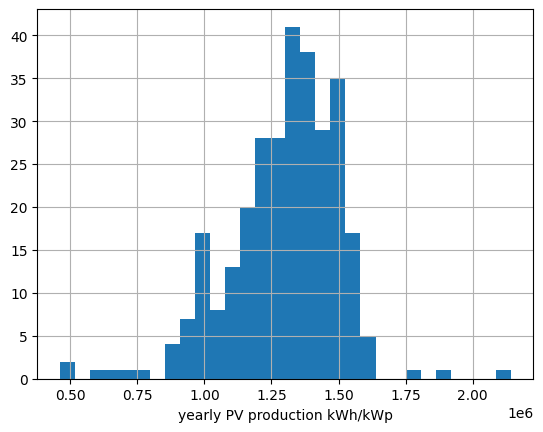

In [70]:
pv_perf.hist(bins=30)
plt.xlabel('yearly PV production kWh/kWp')